In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
import importlib
import utils

importlib.reload(utils)
%matplotlib inline
plt.rcParams.update(
    {
        "font.size": 14,  
        "axes.titlesize": 16,  
        "axes.labelsize": 14,  
        "xtick.labelsize": 12,  
        "ytick.labelsize": 12,  
        "legend.fontsize": 12,  
        "figure.titlesize": 14,  
    }
)

data_dir = "../plotting_data/rsds_spatial_raw/"

# Load Coordinates 
lons = np.loadtxt(os.path.join(data_dir, "lons.txt"))
lats = np.loadtxt(os.path.join(data_dir, "lats.txt"))

# Load Model Names 
with open(os.path.join(data_dir, "model_names_past.txt"), "r") as f:
    model_names_past = f.read().splitlines()

with open(os.path.join(data_dir, "model_names_future.txt"), "r") as f:
    model_names_future = f.read().splitlines()

In [8]:
folder_path = "../plotting_data/rsds_spatial"
# List all .npy files
npy_files = [f for f in os.listdir(folder_path) if f.endswith(".npy")]

# Load all files into a dictionary
data = {}
file_names = []
for i in range(len(npy_files)):
    f = npy_files[i]
    file_path = os.path.join(folder_path, f)
    data[i] = np.load(file_path)
    file_names.append(f)

selected_data = {}

top10_indices_sorted = [28, 21, 30, 27, 23, 26, 12, 24, 14, 22, 25, 13, 29, 11, 8]
for key, arr in data.items():
    # arr has shape (31, 4, 12, 30)
    selected_data[key] = arr[top10_indices_sorted, :, :, :]

model_names_past = [model_names_past[i] for i in top10_indices_sorted]
print(model_names_past)

['SMHI_MOHC-HadGEM2-ES', 'MOHC_MOHC-HadGEM2-ES', 'SMHI_NCC-NorESM1-M', 'SMHI_IPSL-IPSL-CM5A-MR', 'MOHC_NCC-NorESM1-M', 'SMHI_ICHEC-EC-EARTH', 'CNRM_MOHC-HadGEM2-ES', 'MOHC_CNRM-CERFACS-CNRM-CM5', 'CNRM_NCC-NorESM1-M', 'MOHC_MPI-M-MPI-ESM-LR', 'SMHI_CNRM-CERFACS-CNRM-CM5', 'CNRM_MPI-M-MPI-ESM-LR', 'SMHI_MPI-M-MPI-ESM-LR', 'CNRM_CNRM-CERFACS-CNRM-CM5', 'DMI_MOHC-HadGEM2-ES']


['SMHI_MOHC-HadGEM2-ES', 'MOHC_MOHC-HadGEM2-ES', 'SMHI_NCC-NorESM1-M', 'SMHI_IPSL-IPSL-CM5A-MR', 'MOHC_NCC-NorESM1-M', 'SMHI_ICHEC-EC-EARTH', 'CNRM_MOHC-HadGEM2-ES', 'MOHC_CNRM-CERFACS-CNRM-CM5', 'CNRM_NCC-NorESM1-M', 'MOHC_MPI-M-MPI-ESM-LR', 'SMHI_CNRM-CERFACS-CNRM-CM5', 'CNRM_MPI-M-MPI-ESM-LR', 'SMHI_MPI-M-MPI-ESM-LR', 'CNRM_CNRM-CERFACS-CNRM-CM5', 'DMI_MOHC-HadGEM2-ES']


/tmp/ipykernel_771785/2884868190.py:30: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(


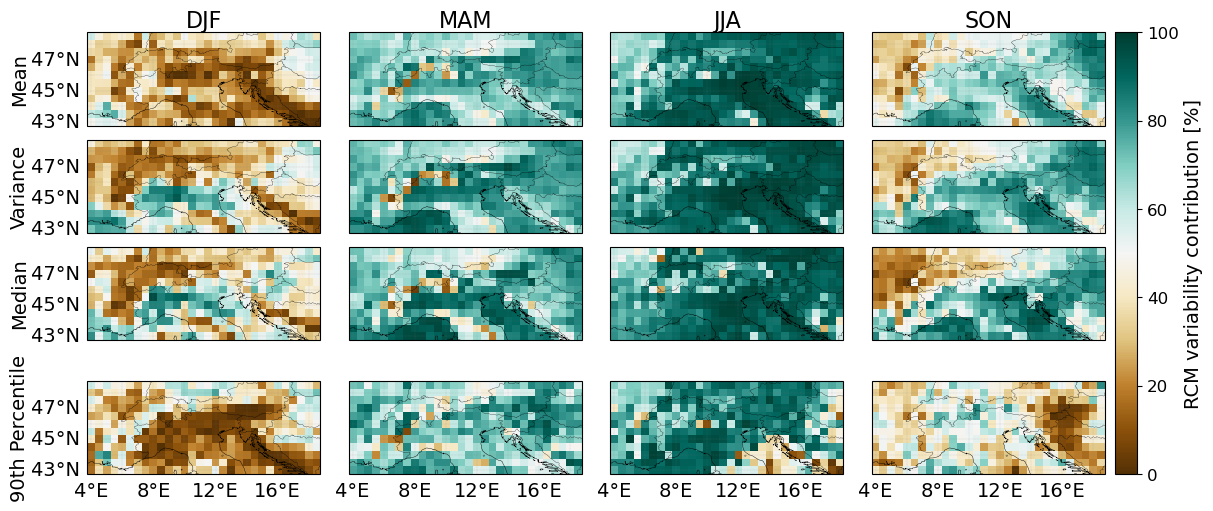

In [ ]:
rcm_labels = np.array([name.split("_")[0] for name in model_names_past])
gcm_labels = np.array([name.split("_")[1] for name in model_names_past])
gcm_groups = np.unique(gcm_labels)
rcm_groups = np.unique(rcm_labels)
print(model_names_past)

# --- Plotting setup ---
norm = TwoSlopeNorm(vmin=0, vcenter=50, vmax=100)
cmap = plt.get_cmap("BrBG")
seasons = ["DJF", "MAM", "JJA", "SON"]

selected_files = [
    "marginal_average_seasonal_hourly_abs.npy",
    "marginal_var_seasonal.npy",
    "spatiotemporal_below_percentile_seasonal.npy",
    "spatiotemporal_above_percentile_seasonal.npy",
]

fig, axes = plt.subplots(
    len(selected_files),
    len(seasons),
    figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = axes.flatten()
plt.subplots_adjust(
    left=0.02, right=0.98, top=0.93, bottom=0.05, wspace=0.05, hspace=0.001
)

# --- Loop over files and seasons ---
for i, name in enumerate(selected_files):
    idx = [j for j, n in enumerate(file_names) if n == name]
    if not idx:
        continue
    score = idx[0]
    ds = np.asarray(selected_data[score])
    # --- Compute variance fractions ---
    var_gcm, var_rcm, _, _ = utils.compute_anova_variance(ds, gcm_labels, rcm_labels)
    relative_var = var_rcm / (var_gcm + var_rcm) * 100  # RCM / GCM ratio

    for j, season in enumerate(seasons):
        ax = axes[i * len(seasons) + j]
        if i == 0:
            ax.set_title(season, pad=2)
        ax.coastlines(linewidth=0.3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.2)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

        im = ax.pcolormesh(
            lons,
            lats,
            relative_var[j],
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm,
            rasterized=True,
        )

        gl = ax.gridlines(
            draw_labels=True, linewidth=0.2, color="gray", alpha=0.5, linestyle="--"
        )
        gl.bottom_labels = i == len(selected_files) - 1
        gl.top_labels = False
        gl.left_labels = j == 0
        gl.right_labels = False

# --- Shared colorbar ---
cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.025, pad=0.01)
cbar.set_label("RCM variability contribution [%]")
row_labels = ["Mean", "Variance", "Median", "90th Percentile"]
for i, label in enumerate(row_labels):
    ax_row = axes[i * len(seasons)]  # first column of each row
    ax_row.annotate(
        label,
        xy=(-0.25, 0.5),  # relative to axes
        xycoords="axes fraction",
        va="center",
        ha="right",
        fontsize=14,
        rotation="vertical",
    )
plt.savefig("../plot/0066_overview_anova_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
bottom10_indices_sorted = [0, 2, 3, 22, 24, 23, 4, 1, 19, 15, 20, 21, 17, 16, 8]

with open(os.path.join(data_dir, "model_names_past.txt"), "r") as f:
    model_names_past = f.read().splitlines()
model_names_past = [model_names_past[i] for i in bottom10_indices_sorted]

['CLMcom-ETH_ICHEC-EC-EARTH', 'CLMcom-ETH_MPI-M-MPI-ESM-LR', 'CLMcom-ETH_NCC-NorESM1-M', 'MOHC_MPI-M-MPI-ESM-LR', 'MOHC_CNRM-CERFACS-CNRM-CM5', 'MOHC_NCC-NorESM1-M', 'CLMcom-ETH_CNRM-CERFACS-CNRM-CM5', 'CLMcom-ETH_MOHC-HadGEM2-ES', 'KNMI_MPI-M-MPI-ESM-LR', 'KNMI_CNRM-CERFACS-CNRM-CM5', 'KNMI_NCC-NorESM1-M', 'MOHC_MOHC-HadGEM2-ES', 'KNMI_IPSL-IPSL-CM5A-MR', 'KNMI_ICHEC-EC-EARTH', 'DMI_MOHC-HadGEM2-ES']


/tmp/ipykernel_771785/4278295506.py:36: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(


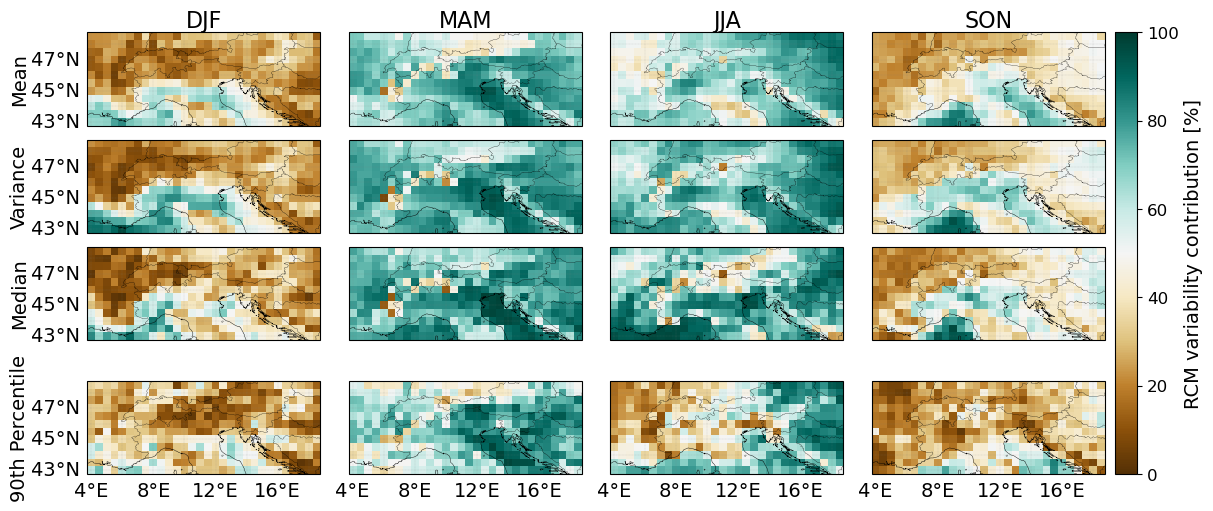

In [11]:
print(model_names_past)
selected_data = {}

for key, arr in data.items():
    # arr has shape (31, 4, 12, 30)
    selected_data[key] = arr[bottom10_indices_sorted, :, :, :]

# --- Labels ---
rcm_labels = np.array([name.split("_")[0] for name in model_names_past])
gcm_labels = np.array([name.split("_")[1] for name in model_names_past])
gcm_groups = np.unique(gcm_labels)
rcm_groups = np.unique(rcm_labels)

norm = TwoSlopeNorm(vmin=0, vcenter=50, vmax=100)
cmap = plt.get_cmap("BrBG")
seasons = ["DJF", "MAM", "JJA", "SON"]

selected_files = [
    "marginal_average_seasonal_hourly_abs.npy",
    "marginal_var_seasonal.npy",
    "spatiotemporal_below_percentile_seasonal.npy",
    "spatiotemporal_above_percentile_seasonal.npy",
]

# --- 4x4 subplot layout ---
fig, axes = plt.subplots(
    len(selected_files),
    len(seasons),
    figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = axes.flatten()
plt.subplots_adjust(
    left=0.02, right=0.98, top=0.93, bottom=0.05, wspace=0.05, hspace=0.001
)

# --- Loop over files and seasons ---
for i, name in enumerate(selected_files):
    idx = [j for j, n in enumerate(file_names) if n == name]
    if not idx:
        continue
    score = idx[0]
    ds = np.asarray(selected_data[score])
    # --- Compute variance fractions ---
    var_gcm, var_rcm, _, _ = utils.compute_anova_variance(ds, gcm_labels, rcm_labels)
    zero_gcm = np.sum(var_gcm[0] == 0)  # DJF = season 0
    zero_rcm = np.sum(var_rcm[0] == 0)
    # Count NaNs
    nan_gcm = np.sum(np.isnan(var_gcm[0]))
    nan_rcm = np.sum(np.isnan(var_rcm[0]))
    relative_var = var_rcm / (var_rcm + var_gcm) * 100  # RCM / GCM ratio

    for j, season in enumerate(seasons):
        ax = axes[i * len(seasons) + j]
        if i == 0:
            ax.set_title(season, pad=2)
        ax.coastlines(linewidth=0.3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.2)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

        im = ax.pcolormesh(
            lons,
            lats,
            relative_var[j],
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm,
            rasterized=True,
        )

        gl = ax.gridlines(
            draw_labels=True, linewidth=0.2, color="gray", alpha=0.5, linestyle="--"
        )
        gl.bottom_labels = i == len(selected_files) - 1
        gl.top_labels = False
        gl.left_labels = j == 0
        gl.right_labels = False

# --- Shared colorbar ---
cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.025, pad=0.01)
cbar.set_label("RCM variability contribution [%]")
row_labels = ["Mean", "Variance", "Median", "90th Percentile"]
for i, label in enumerate(row_labels):
    ax_row = axes[i * len(seasons)]  # first column of each row
    ax_row.annotate(
        label,
        xy=(-0.25, 0.5),  # relative to axes
        xycoords="axes fraction",
        va="center",
        ha="right",
        fontsize=14,
        rotation="vertical",
    )
plt.savefig("../plot/0066_overview_anova_mape.png", dpi=300, bbox_inches="tight")
plt.show()